# Linear Regression for Non linear data

In [1]:
import numpy as np
rng = np.random.RandomState(0)
n_sample = 100
data_max, data_min = 1.4, -1.4
len_data = data_max - data_min
data = np.sort(rng.rand(n_sample) * len_data - len_data / 2)
noise = rng.randn(n_sample) * 0.3
target = data**3 - 0.5 * data**2 + noise

In [2]:
import pandas as pd

full_data = pd.DataFrame({"input_feature": data, "target": target})

In [4]:
full_data.head()

,input_feature,target
0,-1.386853,-3.978642
1,-1.347389,-3.083605
2,-1.343699,-3.189149
3,-1.343388,-3.787623
4,-1.290274,-2.533986


In [10]:
full_data.describe()

,input_feature,target
count,100.000000,100.000000
mean,-0.076177,-0.384235
std,0.811311,1.133431
min,-1.386853,-3.978642
25%,-0.823751,-0.867434
50%,-0.091053,-0.081510
75%,0.516553,0.194998
max,1.367447,1.627292


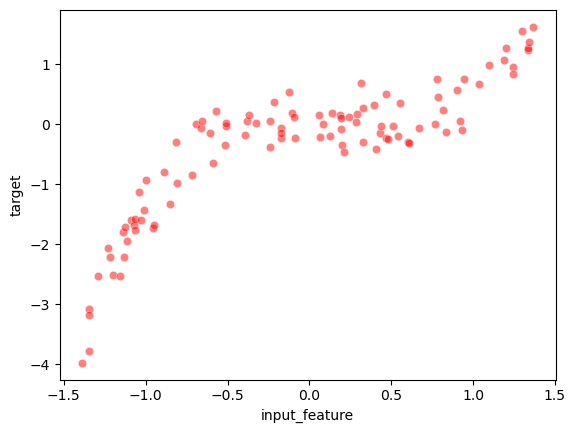

In [14]:
import seaborn as sns

_ = sns.scatterplot(
    data=full_data, x="input_feature", y="target", color="red", alpha=0.5
)

In [15]:
data.shape

(100,)

In [16]:
data = data.reshape((-1,1))
data.shape

(100, 1)

In [17]:
def fit_score_plot_regression(model, title=None):
    model.fit(data, target)
    target_predicted = model.predict(data)
    mse = mean_squared_error(target, target_predicted)
    ax = sns.scatterplot(
        data=full_data, x="input_feature", y="target", color="black", alpha=0.5
    )
    ax.plot(data, target_predicted)
    if title is not None:
        _ = ax.set_title(title + f" (MSE = {mse:.2f})")
    else:
        _ = ax.set_title(f"Mean squared error = {mse:.2f}")

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

linear_regression = LinearRegression()
linear_regression

LinearRegression()

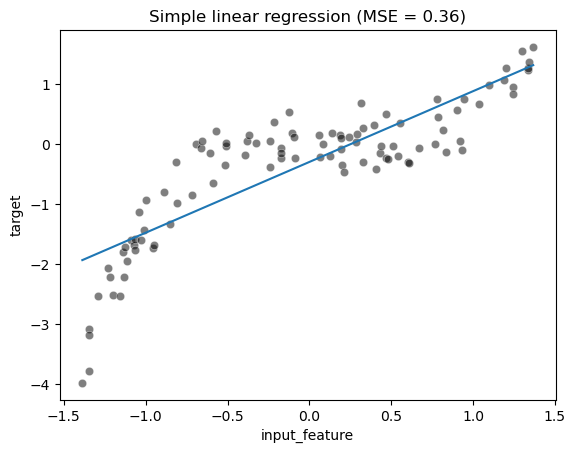

In [19]:
fit_score_plot_regression(linear_regression, title="Simple linear regression")

In [20]:
print(
    f"weight: {linear_regression.coef_[0]:.2f}, "
    f"intercept: {linear_regression.intercept_:.2f}"
)

weight: 1.18, intercept: -0.29


- Linear models asume linear relationship. Thus model was not able to handle this data

In [21]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=3).fit(data, target)
tree

DecisionTreeRegressor(max_depth=3)

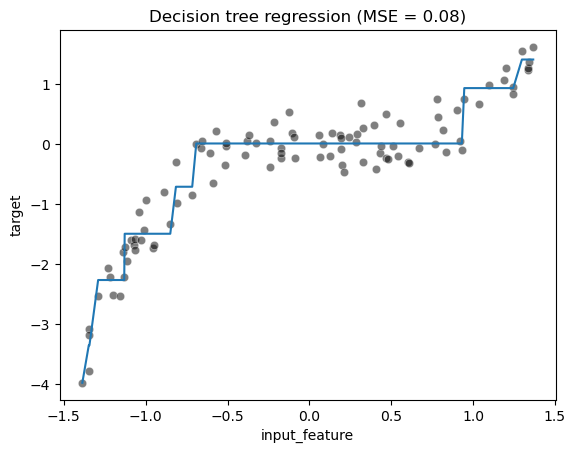

In [22]:
fit_score_plot_regression(tree, title="Decision tree regression")

- Using a non linear model

In [23]:
data_expanded = np.concatenate([data, data**2, data**3], axis=1)
data_expanded.shape

(100, 3)

- modify our data: we could create new features, derived from the original features, using some expert knowledge. In this example, we know that we have a cubic and squared relationship between data and target (because we generated the data)

In [48]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression(),
)
polynomial_regression

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=3, include_bias=False)),
                ('linearregression', LinearRegression())])

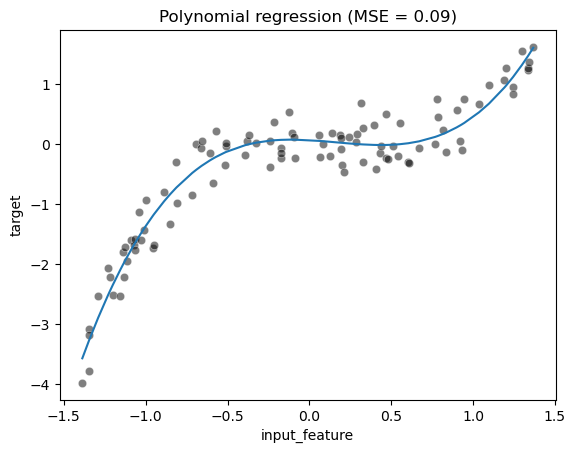

In [49]:
fit_score_plot_regression(polynomial_regression, title="Polynomial regression")

In [50]:
from sklearn.svm import SVR

svr = SVR(kernel="linear")
svr

SVR(kernel='linear')

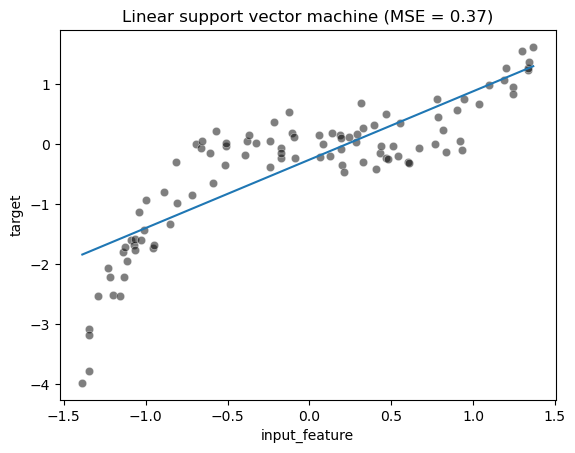

In [51]:
fit_score_plot_regression(svr, title="Linear support vector machine")

In [58]:
svr = SVR(kernel="poly", degree=3)
svr

SVR(kernel='poly')

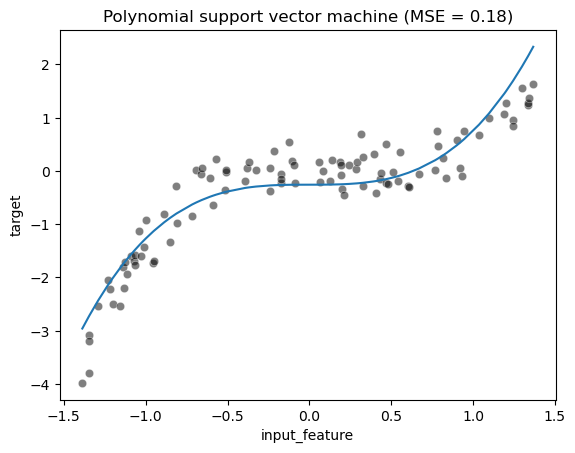

In [59]:
fit_score_plot_regression(svr, title="Polynomial support vector machine")

In [60]:
from sklearn.preprocessing import KBinsDiscretizer

binned_regression = make_pipeline(
    KBinsDiscretizer(n_bins=8),
    LinearRegression(),
)
binned_regression

Pipeline(steps=[('kbinsdiscretizer', KBinsDiscretizer(n_bins=8)),
                ('linearregression', LinearRegression())])

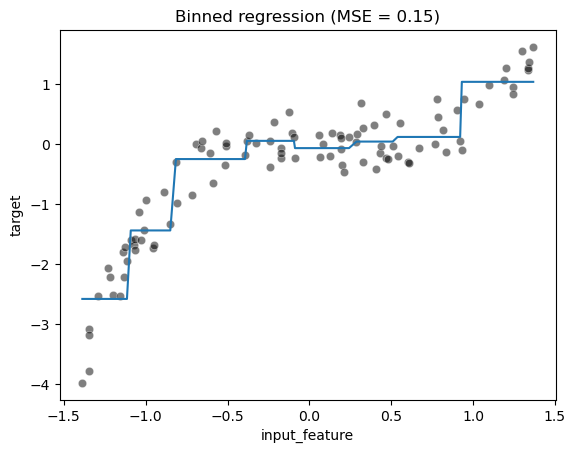

In [61]:
fit_score_plot_regression(binned_regression, title="Binned regression")

In [62]:
from sklearn.preprocessing import SplineTransformer

spline_regression = make_pipeline(
    SplineTransformer(degree=3, include_bias=False),
    LinearRegression(),
)
spline_regression

Pipeline(steps=[('splinetransformer', SplineTransformer(include_bias=False)),
                ('linearregression', LinearRegression())])

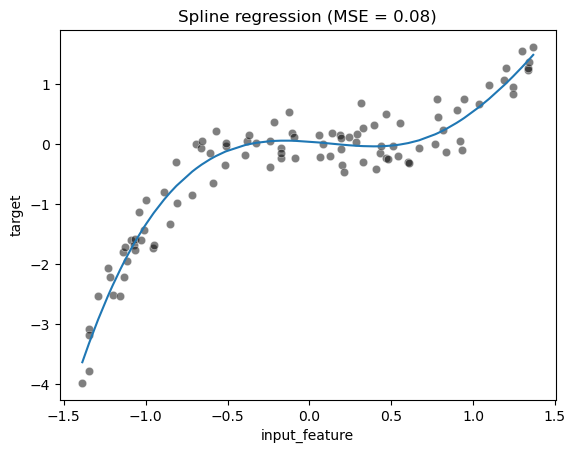

In [63]:
fit_score_plot_regression(spline_regression, title="Spline regression")

In [64]:
from sklearn.kernel_approximation import Nystroem

nystroem_regression = make_pipeline(
    Nystroem(kernel="poly", degree=3, n_components=5, random_state=0),
    LinearRegression(),
)
nystroem_regression

Pipeline(steps=[('nystroem',
                 Nystroem(degree=3, kernel='poly', n_components=5,
                          random_state=0)),
                ('linearregression', LinearRegression())])

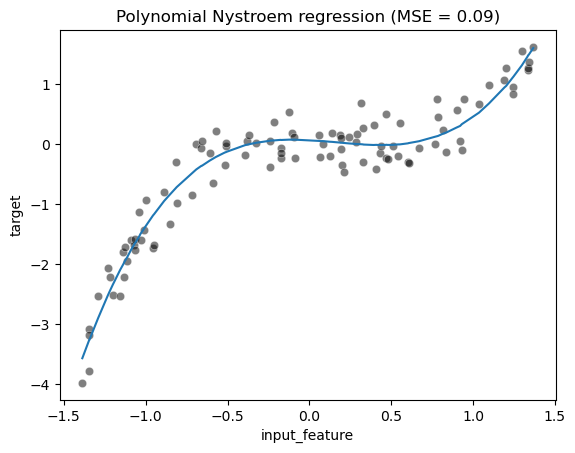

In [65]:
fit_score_plot_regression(
    nystroem_regression, title="Polynomial Nystroem regression"
)